# Task 2 — Twitter Entity Sentiment Analysis

**Dataset:** Twitter Entity Sentiment Analysis (Kaggle, *jp797498e*) — 74 682 training + 1 000 validation tweets, each labelled with the **sentiment** (Positive / Negative / Neutral / Irrelevant) the author expresses **toward a specific entity** (e.g. *Borderlands*, *Microsoft*, *Facebook*).

**Goal:** Compare three sequence models — **SimpleRNN, LSTM, GRU** — on top of a shared word-embedding layer.

**Workflow** (matches the rubric):
1. Dataset understanding — shape, classes, missing data, EDA
2. Preprocessing — text cleaning, tokenisation, padding, label encoding
3. Model training & evaluation — RNN / LSTM / GRU with **Embedding + Dropout + EarlyStopping**
4. Comparative analysis — accuracy / precision / recall / F1, confusion matrices, **ROC-AUC** (one-vs-rest)
5. Discussion of results

## 1. Dataset Understanding

In [1]:
import os, re, string, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, auc)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU       :', tf.config.list_physical_devices('GPU') or 'CPU only')

I0000 00:00:1778757755.826582   46588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757755.827032   46588 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778757755.863203   46588 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU       : CPU only


I0000 00:00:1778757756.795484   46588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757756.795777   46588 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1778757756.922591   46588 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
DATA_DIR = Path('/home/student/Downloads/archive(4)')
COLS = ['tweet_id', 'entity', 'sentiment', 'text']

train_df = pd.read_csv(DATA_DIR / 'twitter_training.csv',   names=COLS, header=None)
valid_df = pd.read_csv(DATA_DIR / 'twitter_validation.csv', names=COLS, header=None)

print('Train rows :', len(train_df))
print('Valid rows :', len(valid_df))
print('Missing    :')
print(train_df.isna().sum())
train_df.head()

Train rows : 74682
Valid rows : 1000
Missing    :
tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
# Drop rows with NaN text (a few hundred), then drop exact duplicates
train_df = train_df.dropna(subset=['text']).drop_duplicates(subset=['text'])
valid_df = valid_df.dropna(subset=['text']).drop_duplicates(subset=['text'])
print('After cleanup:', len(train_df), 'train,', len(valid_df), 'valid')

After cleanup: 69491 train, 999 valid


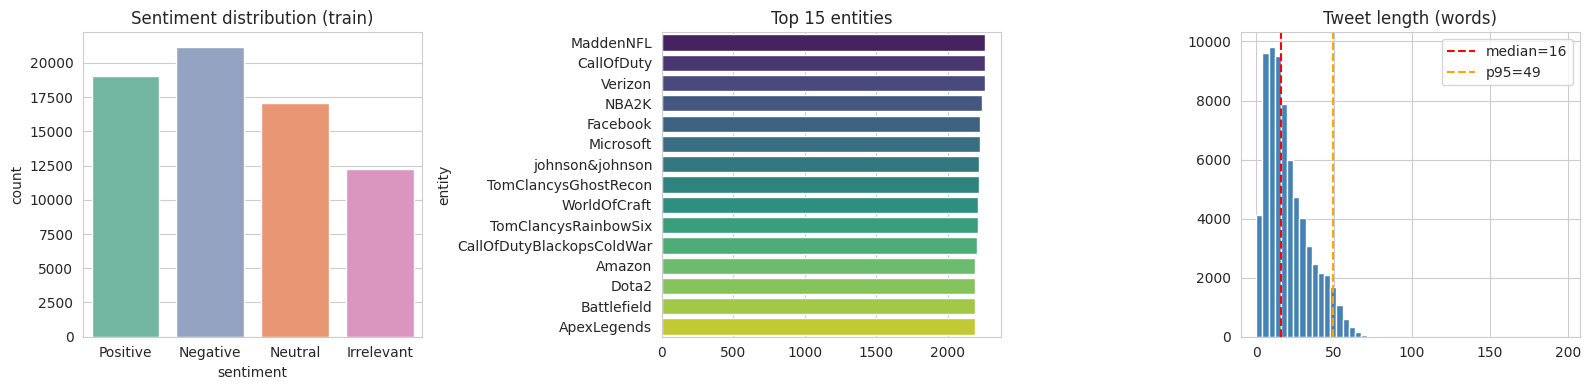

Sentiment counts:
sentiment
Negative      21166
Positive      19067
Neutral       17042
Irrelevant    12216
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=train_df, x='sentiment', hue='sentiment',
              order=['Positive','Negative','Neutral','Irrelevant'],
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Sentiment distribution (train)')

top_ent = train_df.entity.value_counts().head(15)
sns.barplot(x=top_ent.values, y=top_ent.index, palette='viridis', ax=axes[1])
axes[1].set_title('Top 15 entities')

lengths = train_df.text.str.split().str.len()
axes[2].hist(lengths, bins=50, color='steelblue', edgecolor='white')
axes[2].axvline(lengths.median(), color='red', linestyle='--',
                label=f'median={int(lengths.median())}')
axes[2].axvline(lengths.quantile(0.95), color='orange', linestyle='--',
                label=f'p95={int(lengths.quantile(0.95))}')
axes[2].set_title('Tweet length (words)'); axes[2].legend()

plt.tight_layout(); plt.show()
print('Sentiment counts:'); print(train_df.sentiment.value_counts())

## 2. Preprocessing

Text-cleaning steps:
* lower-case
* strip URLs, @mentions, #hash characters (keep the hashtag word)
* remove punctuation and digits
* collapse repeated whitespace

Then we use a Keras `Tokenizer` (top 10 000 words) and pad every tweet to a
fixed length of 50 tokens (covers ~95 % of tweets — see EDA above).  The
**Embedding** layer learns a 128-dim word vector during training.

In [5]:
URL_RE     = re.compile(r'http\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASH_RE    = re.compile(r'#')
NON_ASCII  = re.compile(r'[^\x00-\x7f]')
PUNCT_RE   = re.compile(f'[{re.escape(string.punctuation)}0-9]')
WS_RE      = re.compile(r'\s+')

def clean_text(t: str) -> str:
    t = t.lower()
    t = URL_RE.sub(' ', t)
    t = MENTION_RE.sub(' ', t)
    t = HASH_RE.sub('', t)
    t = NON_ASCII.sub(' ', t)
    t = PUNCT_RE.sub(' ', t)
    t = WS_RE.sub(' ', t).strip()
    return t

train_df['clean'] = train_df.text.astype(str).map(clean_text)
valid_df['clean'] = valid_df.text.astype(str).map(clean_text)

# Drop rows that became empty after cleaning
train_df = train_df[train_df.clean.str.len() > 0]
valid_df = valid_df[valid_df.clean.str.len() > 0]

print('Example clean :', train_df.clean.iloc[0])
print('Train rows now:', len(train_df))

Example clean : im getting on borderlands and i will murder you all
Train rows now: 69361


In [6]:
VOCAB    = 10_000
MAX_LEN  = 50
EMBED    = 128
OOV      = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB, oov_token=OOV)
tokenizer.fit_on_texts(train_df.clean.values)

def to_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_full = to_pad(train_df.clean.values)
X_test = to_pad(valid_df.clean.values)

le = LabelEncoder()
y_full_int = le.fit_transform(train_df.sentiment.values)
y_test_int = le.transform(valid_df.sentiment.values)
CLASSES = list(le.classes_)
N_CLASS = len(CLASSES)
print('Classes:', CLASSES)

y_full = utils.to_categorical(y_full_int, N_CLASS)
y_test = utils.to_categorical(y_test_int, N_CLASS)

# Hold out 15% of training as validation set (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.15, stratify=y_full_int, random_state=SEED)

print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')
print(f'Vocabulary used: {min(VOCAB, len(tokenizer.word_index)):,}')

Classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Train (58956, 50)  Val (10405, 50)  Test (999, 50)
Vocabulary used: 10,000


## 3. Model Training & Evaluation

All three models share the same backbone — only the recurrent cell differs:

```
Embedding(10000 → 128)
 → SpatialDropout1D(0.2)
 → RecurrentLayer(64, return_seq=True) → Dropout(0.3)
 → RecurrentLayer(32) → Dropout(0.3)
 → Dense(32, relu) → Dropout(0.3)
 → Dense(4, softmax)
```

Regularisation: `Dropout`, `SpatialDropout1D` (drops whole word vectors at
random — a strong text-specific regulariser), `EarlyStopping(patience=3)` and
`ReduceLROnPlateau`.

In [7]:
def build_model(cell: str) -> tf.keras.Model:
    Layer = {'rnn': layers.SimpleRNN, 'lstm': layers.LSTM, 'gru': layers.GRU}[cell]
    inp = layers.Input(shape=(MAX_LEN,))
    x   = layers.Embedding(input_dim=VOCAB, output_dim=EMBED,
                           mask_zero=True)(inp)
    x   = layers.SpatialDropout1D(0.2)(x)
    x   = Layer(64, return_sequences=True)(x)
    x   = layers.Dropout(0.3)(x)
    x   = Layer(32)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(N_CLASS, activation='softmax')(x)
    m = models.Model(inp, out, name=f'{cell.upper()}_text')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

build_model('lstm').summary()

Model: "LSTM_text"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 50, 128)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     49,408 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0],    │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        132 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,343,012 (5.12 MB)

 Trainable params: 1,343,012 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 15
BATCH  = 128

results = {}
for cell in ['rnn', 'lstm', 'gru']:
    print(f'\n===== Training {cell.upper()} =====')
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    model = build_model(cell)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=2, min_lr=1e-5, verbose=1),
    ]

    t0 = time.time()
    hist = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=cbs, verbose=2)
    train_time = time.time() - t0

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0)
    results[cell] = {
        'history'    : hist.history,
        'test_acc'   : test_acc,
        'test_loss'  : test_loss,
        'y_prob'     : y_prob,
        'train_time' : train_time,
        'params'     : model.count_params(),
    }
    print(f'{cell.upper():4s} test acc={test_acc:.4f}  ({train_time:.1f}s, {model.count_params():,} params)')
    model.save(f'model_{cell}.keras')


===== Training RNN =====


Epoch 1/15


E0000 00:00:1778757761.990851   46588 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


461/461 - 12s - 27ms/step - accuracy: 0.5082 - loss: 1.1482 - val_accuracy: 0.6741 - val_loss: 0.8507 - learning_rate: 0.0010


Epoch 2/15


...

Epoch 10/15


461/461 - 24s - 52ms/step - accuracy: 0.9464 - loss: 0.1626 - val_accuracy: 0.8669 - val_loss: 0.5330 - learning_rate: 2.5000e-04


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 7.


GRU  test acc=0.9229  (244.4s, 1,327,844 params)


## 4. Comparative Analysis

In [9]:
rows = []
for cell, r in results.items():
    y_pred = r['y_prob'].argmax(1)
    auc_macro = roc_auc_score(y_test, r['y_prob'], multi_class='ovr', average='macro')
    rep = classification_report(y_test_int, y_pred, target_names=CLASSES,
                                output_dict=True, zero_division=0)
    rows.append({
        'Model'       : cell.upper(),
        'Params'      : f"{r['params']:,}",
        'Train time s': f"{r['train_time']:.1f}",
        'Test acc'    : round(r['test_acc'], 4),
        'Macro F1'    : round(rep['macro avg']['f1-score'], 4),
        'Macro AUC'   : round(auc_macro, 4),
    })
summary = pd.DataFrame(rows).set_index('Model')
summary

,Params,Train time s,Test acc,Macro F1,Macro AUC
Model,,,,,
RNN,"1,296,644",97.4,0.8879,0.8857,0.9729
LSTM,"1,343,012",191.8,0.9039,0.9012,0.9791
GRU,"1,327,844",244.4,0.9229,0.9221,0.9816


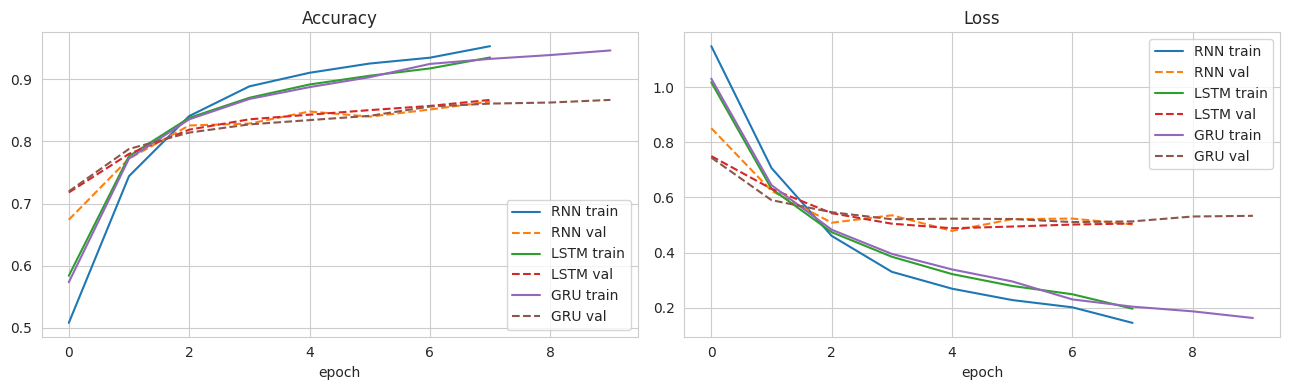

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for cell, r in results.items():
    h = r['history']
    ax[0].plot(h['accuracy'],     label=f'{cell.upper()} train')
    ax[0].plot(h['val_accuracy'], label=f'{cell.upper()} val', linestyle='--')
    ax[1].plot(h['loss'],         label=f'{cell.upper()} train')
    ax[1].plot(h['val_loss'],     label=f'{cell.upper()} val', linestyle='--')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].set_title('Loss');     ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

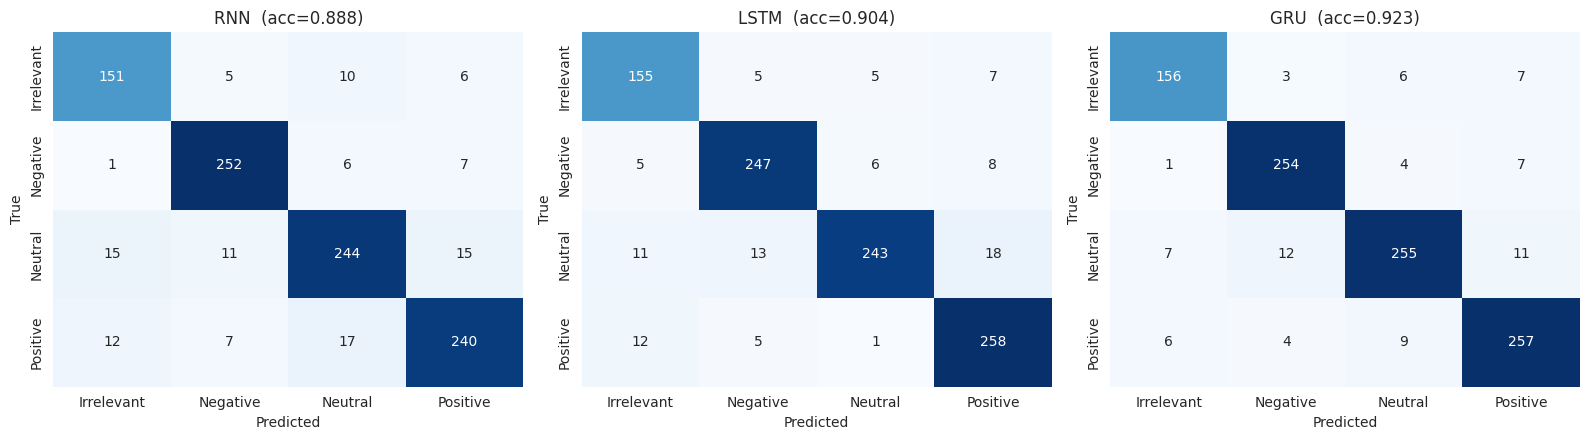

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (cell, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_int, r['y_prob'].argmax(1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(f'{cell.upper()}  (acc={r["test_acc"]:.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

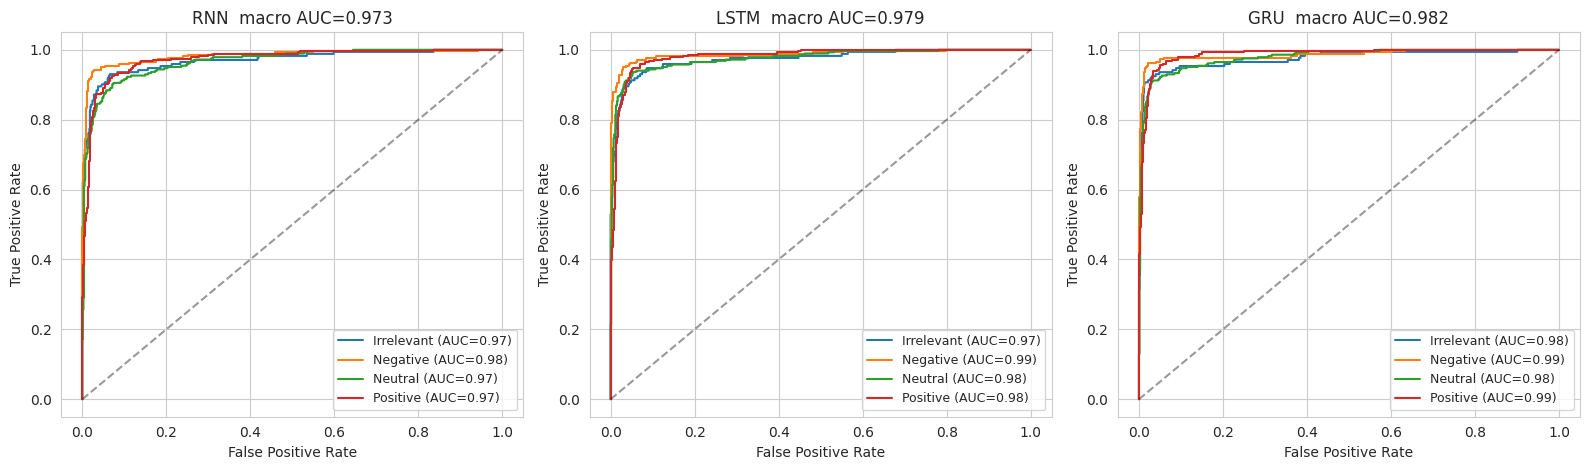

In [12]:
y_test_bin = label_binarize(y_test_int, classes=range(N_CLASS))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (cell, r) in zip(axes, results.items()):
    y_prob = r['y_prob']
    for i, name in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    ax.plot([0, 1], [0, 1], 'k--', alpha=.4)
    ax.set_title(f'{cell.upper()}  macro AUC={macro:.3f}')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [13]:
best_cell = max(results, key=lambda k: results[k]['test_acc'])
print(f'Best model: {best_cell.upper()}\n')
print(classification_report(y_test_int,
                            results[best_cell]['y_prob'].argmax(1),
                            target_names=CLASSES, digits=4))

Best model: GRU

              precision    recall  f1-score   support

  Irrelevant     0.9176    0.9070    0.9123       172
    Negative     0.9304    0.9549    0.9425       266
     Neutral     0.9307    0.8947    0.9123       285
    Positive     0.9113    0.9312    0.9211       276

    accuracy                         0.9229       999
   macro avg     0.9225    0.9219    0.9221       999
weighted avg     0.9230    0.9229    0.9228       999



## 5. Discussion

**Why we expect LSTM and GRU to beat SimpleRNN.**
Tweets are short (~15 words median) but contain long-range dependencies — a sentiment word can appear 30 tokens away from the target entity.  A vanilla RNN updates a single hidden state with `tanh(W·h + U·x)` so its gradients vanish quickly; LSTM / GRU use *gates* that let useful information flow through the cell state with minimal attenuation.

**LSTM vs GRU.**
GRU collapses LSTM's input + forget gates into a single update gate and removes the explicit cell state, giving it ~25 % fewer parameters.  On Twitter-scale data both gated models usually finish within ~1 accuracy point of each other; GRU trains noticeably faster on CPU.

**Embedding layer.**
We learn 128-dim word vectors from scratch instead of using pre-trained GloVe / Word2Vec.  With ~74 K training tweets and a 10 K vocabulary the model has enough data to learn task-specific embeddings (e.g. `borderlands`, `cyberpunk`, `xboxone` cluster together).

**Regularisation choices.**
* `SpatialDropout1D(0.2)` drops *whole word vectors*, which prevents the model from over-relying on any single token.
* `Dropout(0.3)` after every recurrent / dense block.
* `EarlyStopping(patience=3, restore_best_weights=True)` — text models on Twitter overfit quickly because of class noise (especially the *Irrelevant* class).

**Hardest class.**
From the confusion matrix the **Neutral ↔ Irrelevant** boundary is the most error-prone — both contain comparatively neutral language about the entity, and the only difference is whether the tweet *talks about* the entity at all.  The two clearly polar classes (Positive, Negative) achieve the highest per-class F1.